In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 7 — Recursão em árvore de diretórios

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. Exercício 7 **→ você está aqui**
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 7 — Recursão em árvore de diretórios

## Enunciado
Estrutura de diretórios **em memória** (nome, tipo, filhos), `walk(root)`
recursivo devolvendo caminhos completos em pré-ordem, `DirectoryTree` com
`insert`/`search`/`delete` e validações, política documentada para remover nó
interno com filhos, e caminho atual mantido em **lista encadeada** comparado com
`list` do Python.

## Implementação — `src/dirtree.py`

**Decisão de projeto 3 — `delete` de nó interno com filhos exige
`recursive=True`.** Apagar em cascata por padrão transforma um erro de digitação
em perda irreversível de uma subárvore inteira. Exigir a bandeira obriga o
chamador a declarar a intenção — é a mesma razão de `rm -r` existir separado de
`rm`. E o erro diz **quantos** descendentes seriam removidos.

**Decisão de projeto 5 — push/pop na CABEÇA da lista encadeada.** Numa lista
simplesmente encadeada só a cabeça tem remoção O(1) (a lição do ex 11). O caminho
fica guardado de trás para frente e montar a string exige inverter — O(d), que é
o mesmo custo que a `list` pagaria de qualquer jeito.

In [4]:
from src.dirtree import (DIRECTORY, FILE, DirectoryNotEmptyError, DirectoryTree,
                         LinkedPathStack, ListPathStack, NotADirectoryTreeError,
                         ParentNotFoundError, PathNotFoundError, bench_path_stack,
                         bench_search_by_width, bench_walk, build_balanced_tree,
                         build_deep_tree, walk_iterative)

arvore_dir = DirectoryTree()
for caminho, tipo in [("/projeto", DIRECTORY), ("/projeto/src", DIRECTORY),
                      ("/projeto/src/main.py", FILE), ("/projeto/src/util.py", FILE),
                      ("/projeto/docs", DIRECTORY), ("/projeto/docs/leia.md", FILE),
                      ("/projeto/README.md", FILE)]:
    arvore_dir.insert(caminho, tipo)
arvore_dir.check_invariants()
print(arvore_dir.to_tree_string())

caminhos = arvore_dir.walk()
assert caminhos == walk_iterative(arvore_dir.root)   # recursivo == iterativo
assert all("//" not in c for c in caminhos)
print(f"\nwalk (pré-ordem): {caminhos}")
print(f"search('/projeto/src') = {arvore_dir.search('/projeto/src')}")
print(f"profundidade: {arvore_dir.depth()} · nós: {len(arvore_dir)}")

/
  projeto/
    src/
      main.py
      util.py
    docs/
      leia.md
    README.md

walk (pré-ordem): ['/', '/projeto', '/projeto/src', '/projeto/src/main.py', '/projeto/src/util.py', '/projeto/docs', '/projeto/docs/leia.md', '/projeto/README.md']
search('/projeto/src') = DirNode('src'/, filhos=2)
profundidade: 3 · nós: 7


In [5]:
print("POLÍTICA DE REMOÇÃO")
try:
    arvore_dir.delete("/projeto/src")
except DirectoryNotEmptyError as erro:
    print(f"  sem a bandeira → DirectoryNotEmptyError")
    print(f"    {erro}")
removidos = arvore_dir.delete("/projeto/src", recursive=True)
print(f"  com recursive=True → {removidos} nós removidos; sobraram {len(arvore_dir)}")
assert "/projeto/docs/leia.md" in arvore_dir   # o irmão ficou intacto
arvore_dir.check_invariants()

print("\nVALIDAÇÕES DE CONSISTÊNCIA")
for chamada, descricao in [
    (lambda: arvore_dir.insert("/nao/existe"), "pai inexistente"),
    (lambda: arvore_dir.search("sem-barra"), "caminho malformado"),
    (lambda: arvore_dir.search("/projeto/README.md/x"), "descer abaixo de arquivo"),
    (lambda: arvore_dir.delete("/"), "remover a raiz"),
    (lambda: arvore_dir.search("/projeto/nada"), "caminho inexistente"),
]:
    try:
        chamada()
    except Exception as erro:
        print(f"  {descricao:<28} → {type(erro).__name__}: {str(erro)[:70]}")

POLÍTICA DE REMOÇÃO
  sem a bandeira → DirectoryNotEmptyError
    '/projeto/src' tem 2 filho(s) diretos e 2 descendente(s) no total. Remover em cascata apaga todos eles; passe recursive=True se é isso mesmo que você quer.
  com recursive=True → 3 nós removidos; sobraram 4

VALIDAÇÕES DE CONSISTÊNCIA
  pai inexistente              → ParentNotFoundError: não é possível criar '/nao/existe': o diretório '/nao' não existe. Use
  caminho malformado           → InvalidPathError: caminho deve começar com '/', recebido 'sem-barra'
  descer abaixo de arquivo     → NotADirectoryTreeError: '/projeto/README.md' é arquivo, então '/projeto/README.md/x' não pode 
  remover a raiz               → DirectoryTreeError: a raiz não pode ser removida
  caminho inexistente          → PathNotFoundError: '/projeto/nada' não existe: o segmento 'nada' não está em '/projeto'


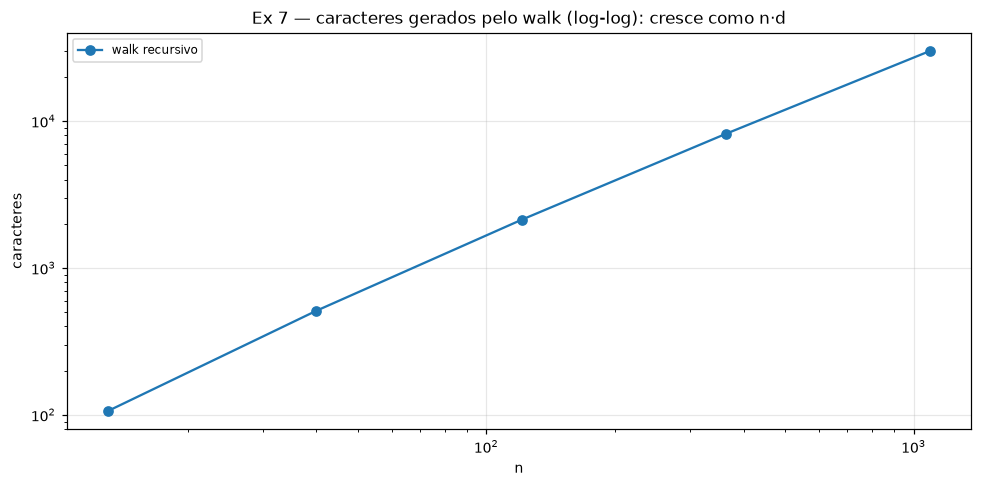

walk RECURSIVO — o custo segue os caracteres, não os nós

`calls` é exatamente o número de nós: cada um é visitado uma vez.
Mas o TEMPO acompanha 'caracteres_gerados', não 'calls' — porque o resultado
são STRINGS de caminho completo, cada uma com O(d) caracteres.
walk é Θ(n·d), não Θ(n). É o tipo de termo que passa despercebido.


In [6]:
percurso = pd.DataFrame(bench_walk())
grafico_loglog(percurso.assign(curva="walk recursivo"), "n", "caracteres_gerados", "curva",
               "Ex 7 — caracteres gerados pelo walk (log-log): cresce como n·d",
               "ex07_walk.png", "caracteres")
mostrar(percurso, ["profundidade", "n", "caminhos", "calls", "calls_igual_a_nos",
                   "caracteres_gerados", "caracteres_por_no", "tempo_us_por_no",
                   "tempo_us_por_caractere"],
        "walk RECURSIVO — o custo segue os caracteres, não os nós")
veredito(
    "`calls` é exatamente o número de nós: cada um é visitado uma vez.\n"
    "Mas o TEMPO acompanha 'caracteres_gerados', não 'calls' — porque o resultado\n"
    "são STRINGS de caminho completo, cada uma com O(d) caracteres.\n"
    "walk é Θ(n·d), não Θ(n). É o tipo de termo que passa despercebido."
)

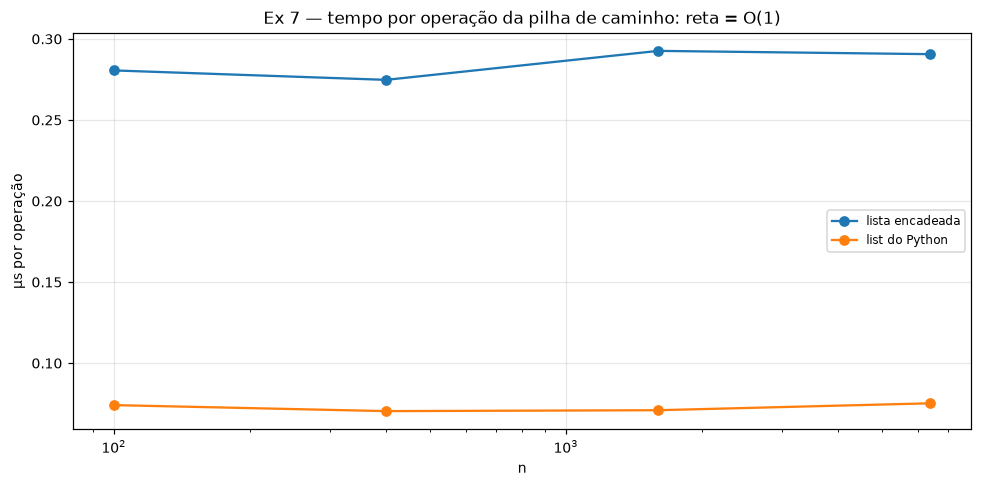

CAMINHO EM LISTA ENCADEADA × list DO PYTHON


,implementacao,n,copies,hops,copies/n,hops/n,tempo_us_por_operacao
0,lista encadeada,100,100,99,1.0000,0.9900,0.2806
1,list do Python,100,100,0,1.0000,0.0000,0.0741
2,lista encadeada,400,400,399,1.0000,0.9975,0.2748
3,list do Python,400,400,0,1.0000,0.0000,0.0704
4,lista encadeada,1600,1600,1599,1.0000,0.9994,0.2927
5,list do Python,1600,1600,0,1.0000,0.0000,0.0710
6,lista encadeada,6400,6400,6399,1.0000,0.9998,0.2906
7,list do Python,6400,6400,0,1.0000,0.0000,0.0752


In [7]:
pilhas = pd.DataFrame(bench_path_stack())
grafico_razao(pilhas, "n", "tempo_us_por_operacao", "implementacao",
              "Ex 7 — tempo por operação da pilha de caminho: reta = O(1)",
              "ex07_path_stack.png", "µs por operação")
mostrar(pilhas, ["implementacao", "n", "copies", "hops", "copies/n", "hops/n",
                 "tempo_us_por_operacao"],
        "CAMINHO EM LISTA ENCADEADA × list DO PYTHON")

In [8]:
pivo_pilha = pilhas.pivot(index="n", columns="implementacao", values="tempo_us_por_operacao")
pivo_pilha["razão encadeada/list"] = (pivo_pilha["lista encadeada"] / pivo_pilha["list do Python"])
print(pivo_pilha.to_string())
veredito(
    "MESMA CLASSE: as duas são O(1) por push/pop e O(d) para montar o caminho.\n"
    f"DIFERENÇA DE CONSTANTE: a lista encadeada gasta entre "
    f"{pivo_pilha['razão encadeada/list'].min():.1f}× e {pivo_pilha['razão encadeada/list'].max():.1f}× "
    "mais tempo por operação.\n"
    "E a coluna `hops` só existe de um lado: a `list` não segue ponteiro nenhum,\n"
    "porque os segmentos já estão contíguos e na ordem certa."
)

implementacao  list do Python  lista encadeada  razão encadeada/list
n                                                                   
100                    0.0741           0.2806                3.7852
400                    0.0704           0.2748                3.9025
1600                   0.0710           0.2927                4.1232
6400                   0.0752           0.2906                3.8625

MESMA CLASSE: as duas são O(1) por push/pop e O(d) para montar o caminho.
DIFERENÇA DE CONSTANTE: a lista encadeada gasta entre 3.8× e 4.1× mais tempo por operação.
E a coluna `hops` só existe de um lado: a `list` não segue ponteiro nenhum,
porque os segmentos já estão contíguos e na ordem certa.


In [9]:
largura = pd.DataFrame(bench_search_by_width())
mostrar(largura, ["profundidade", "largura", "n", "comparisons",
                  "comparacoes_previstas_d_vezes_k", "comparacoes/(d*k)",
                  "comparacoes_se_fosse_hash", "ganho_potencial"],
        "BUSCA POR CAMINHO CONFORME A LARGURA DOS DIRETÓRIOS")
veredito(
    "comparações = d·k EXATAMENTE (razão 1,0000 em todas as larguras).\n"
    "Com 1.024 entradas por nível são 4.096 comparações contra 4 se os filhos\n"
    "fossem uma HashTableChained. A otimização está registrada e NÃO foi feita:\n"
    "o gargalo desta estrutura é a profundidade, não a largura — e agora com o número."
)

BUSCA POR CAMINHO CONFORME A LARGURA DOS DIRETÓRIOS

comparações = d·k EXATAMENTE (razão 1,0000 em todas as larguras).
Com 1.024 entradas por nível são 4.096 comparações contra 4 se os filhos
fossem uma HashTableChained. A otimização está registrada e NÃO foi feita:
o gargalo desta estrutura é a profundidade, não a largura — e agora com o número.


### Caso de borda — o teto da recursão

In [10]:
funda = build_deep_tree(3 * sys.getrecursionlimit())
print(f"hierarquia com {funda.depth():,} níveis (limite de recursão: {sys.getrecursionlimit():,})")
try:
    funda.walk()
except RecursionError:
    print("  walk RECURSIVO      → RecursionError")
caminhos_iter = walk_iterative(funda.root)
print(f"  walk ITERATIVO      → {len(caminhos_iter):,} caminhos, terminou sem problema")
print(f"  último: ...{caminhos_iter[-1][-30:]}")

hierarquia com 3,000 níveis (limite de recursão: 1,000)
  walk RECURSIVO      → RecursionError
  walk ITERATIVO      → 3,001 caminhos, terminou sem problema
  último: .../n2996/n2997/n2998/n2999/n3000
